# Importación de librerias de trabajo

# Programa o Script realizado por :
# Rolando Ortiz Herbas

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import numpy as np
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Lectura del dataset Limpio

In [4]:
ruta = "C:/Users/Roland/Documents/GitHub/Proyecto-I-y-II-MatUNADM/DatosClientes/Clientes_Dos_Mil_numeros.csv"
datasetT = pd.read_csv(ruta)
dataframe = datasetT

In [ ]:
datasetT.info()

# Ver la informacion leida del dataset

In [5]:
datasetT.head()


,Ocupacion,NoPago,TotalMonto,EstadoContrato,Producto,FechaInicioC,FechaAdjudicación,FechaUltimoPago,FechaProyectadaFin,MontoVencido,...,Genero,PersonaTipo,dtEstadoContrato,GrupoOrigenVenta,SemanasAdjud,Pagos9,Domicilia_Pago,Email,timetotV,Y
0,47.0,35,302783,6.0,0.0,20150417,20150417,20180221,20200417,5046,...,1.0,0.0,2.0,1.0,0.0,9,1,1,36,1
1,38.0,38,211366,5.0,0.0,20150220,20150220,20180208,20200220,7044,...,0.0,0.0,2.0,3.0,0.0,9,1,1,40,1
2,13.0,50,323640,1.0,0.0,20150220,20160115,20190218,20200220,0,...,1.0,0.0,1.0,3.0,47.0,8,1,1,50,1
3,59.0,60,377036,1.0,0.0,20150417,20150717,20200305,20200417,12566,...,1.0,0.0,1.0,3.0,13.0,9,0,1,61,1
4,97.0,45,392349,6.0,0.0,20150417,20150417,20181226,20200417,6539,...,0.0,1.0,2.0,3.0,0.0,9,0,1,46,1


In [6]:
datasetT = dataframe.drop(['Y'], axis=1) # quito la variable dependiente "Y"

# estandarización de datos 

In [7]:
# Calcular la media y la desviación estándar de cada columna
mean_A = np.mean(datasetT, axis=0)  # Media por columna
std_A = np.std(datasetT, axis=0)    # Desviación estándar por columna

In [ ]:
print(mean_A)


In [8]:
A_standardized = (datasetT - mean_A)
X_scaled = A_standardized

In [9]:
#Instanciamos objeto PCA y aplicamos
pca=PCA(n_components=26) # Otra opción es instanciar pca sólo con dimensiones nuevas hasta obtener un mínimo "explicado" ej.: pca=PCA(.85)
pca.fit(X_scaled) # obtener los componentes principales
X_pca=pca.transform(X_scaled) # convertimos nuestros datos con las nuevas dimensiones de PCA

In [10]:
expl = pca.explained_variance_ratio_
print(expl)
print('suma:',sum(expl[0:2]))
#con 5 componentes tenemos algo mas del 85% de varianza explicada

[9.22640056e-01 5.69474394e-02 1.07836978e-02 5.54441729e-03
 2.07548605e-03 1.78040271e-03 2.27026696e-04 1.36567061e-06
 8.28784253e-08 1.32768245e-08 9.53892463e-09 1.95245361e-09
 5.28650020e-10 1.47676922e-10 1.24821580e-10 7.87702605e-11
 4.99580510e-11 1.86874022e-11 1.66534101e-11 1.05544842e-11
 1.01719128e-11 4.63886811e-12 3.77928835e-12 2.20189362e-12
 1.63509947e-12 1.35514467e-12]
suma: 0.9795874951354591


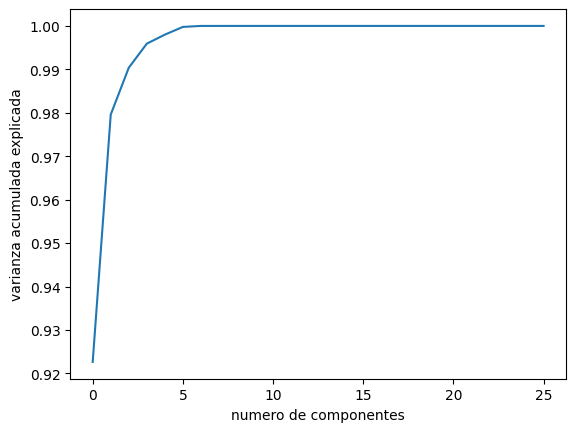

In [12]:
#graficamos el acumulado de varianza explicada en las nuevas dimensiones
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('numero de componentes')
plt.ylabel('varianza acumulada explicada')
plt.show()

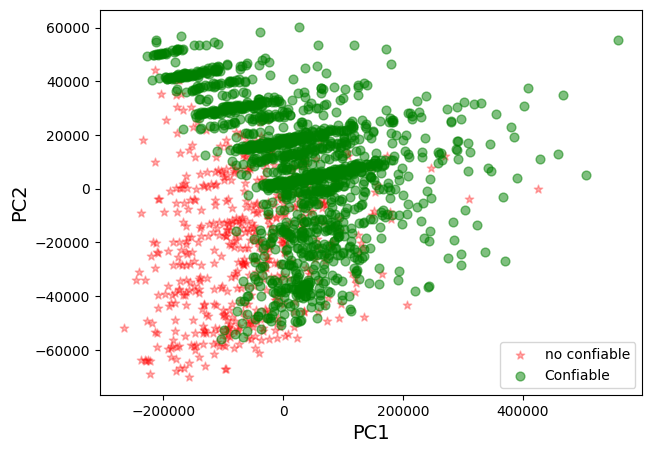

In [13]:
#graficamos en 2 Dimensiones, tomando los 2 primeros componentes principales
Xax=X_pca[:,0]
Yax=X_pca[:,1]
labels=dataframe['Y'].values
cdict={0:'red',1:'green'}
labl={0:'no confiable',1:'Confiable'}
marker={0:'*',1:'o'}
alpha={0:.3, 1:.5}
fig,ax=plt.subplots(figsize=(7,5))
fig.patch.set_facecolor('white')
for l in np.unique(labels):
    ix=np.where(labels==l)
    ax.scatter(Xax[ix],Yax[ix],c=cdict[l],label=labl[l],s=40,marker=marker[l],alpha=alpha[l])
 
plt.xlabel("PC1",fontsize=14)
plt.ylabel("PC2",fontsize=14)
plt.legend()
plt.show()

In [18]:
A = np.matrix([[2, 0], [1, 3]])
evals, evecs = np.linalg.eig(A)

In [19]:
print(evals)

[3. 2.]


In [20]:
print(evecs)

[[ 0.          0.70710678]
 [ 1.         -0.70710678]]


 # Realizar la transformacion de datos

In [ ]:
datasetT.to_csv('C:/Users/Roland/Documents/UNAD_MEXICO_Matematicas_2022/Semestre_2024_1/ZZZ_Word_y_PT/DatosClientes/Clientes_Dos_Mil_numeros.csv', index=False, quoting=csv.QUOTE_NONNUMERIC)